In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd().resolve()

while PROJECT_ROOT.name != "Fraud-detection-ML-V2" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

TEST_FEATURE_PATH = (
    PROCESSED_DATA_DIR
    / "ml_test_features.csv"
)

BASELINE_MODEL_PATH = (
    MODELS_DIR
    / "xgboost_baseline.json"
)

TUNED_MODEL_PATH = (
    MODELS_DIR
    / "xgboost_tuned.json"
)

if not TEST_FEATURE_PATH.exists():
    raise FileNotFoundError(
        f"Test feature file not found:\n{TEST_FEATURE_PATH}"
    )

if not BASELINE_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Baseline model not found:\n{BASELINE_MODEL_PATH}"
    )

if not TUNED_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Tuned model not found:\n{TUNED_MODEL_PATH}"
    )

df = pd.read_csv(
    TEST_FEATURE_PATH
)

ML_FEATURES = [
    "amount",
    "amount_vs_avg_ratio",
    "txn_count_last_5min",
    "time_since_last_txn_sec",
    "distance_from_last_location_km",
    "merchant_category_is_new_for_user"
]

TARGET_COLUMN = "is_fraud"

missing_columns = [
    column
    for column in ML_FEATURES + [TARGET_COLUMN]
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

X_test = df[ML_FEATURES].copy()
y_test = df[TARGET_COLUMN].astype(int).copy()

baseline_model = XGBClassifier()
baseline_model.load_model(
    BASELINE_MODEL_PATH
)

tuned_model = XGBClassifier()
tuned_model.load_model(
    TUNED_MODEL_PATH
)

print("========== PHASE 6 DATA LOADED ==========")
print("Test shape:", df.shape)
print("Test rows:", len(df))
print("ML features:", ML_FEATURES)
print("Number of features:", len(ML_FEATURES))
print("Baseline model loaded:", True)
print("Tuned model loaded:", True)
print("=========================================")

========== PHASE 6 DATA LOADED ==========
Test shape: (555719, 9)
Test rows: 555719
ML features: ['amount', 'amount_vs_avg_ratio', 'txn_count_last_5min', 'time_since_last_txn_sec', 'distance_from_last_location_km', 'merchant_category_is_new_for_user']
Number of features: 6
Baseline model loaded: True
Tuned model loaded: True


In [2]:
if X_test.isnull().any().any():
    raise ValueError(
        "Missing values found in test features."
    )

if not np.isfinite(
    X_test.to_numpy(dtype=float)
).all():
    raise ValueError(
        "Non-finite values found in test features."
    )

if not y_test.isin([0, 1]).all():
    raise ValueError(
        "Test target contains invalid values."
    )

if y_test.nunique() < 2:
    raise ValueError(
        "Test set must contain both legitimate and fraud transactions."
    )

print("========== TEST VALIDATION ==========")
print(
    "Missing feature values:",
    int(X_test.isnull().sum().sum())
)

print(
    "All feature values finite:",
    np.isfinite(
        X_test.to_numpy(dtype=float)
    ).all()
)

print(
    "Target values:",
    sorted(
        y_test.unique().tolist()
    )
)

print(
    "Fraud transactions:",
    int((y_test == 1).sum())
)

print(
    "Legitimate transactions:",
    int((y_test == 0).sum())
)

print("=====================================")

========== TEST VALIDATION ==========
Missing feature values: 0
All feature values finite: True
Target values: [0, 1]
Fraud transactions: 2145
Legitimate transactions: 553574


In [3]:
baseline_test_probability = (
    baseline_model.predict_proba(
        X_test
    )[:, 1]
)

tuned_test_probability = (
    tuned_model.predict_proba(
        X_test
    )[:, 1]
)

baseline_test_prediction = (
    baseline_test_probability >= 0.5
).astype(int)

tuned_test_prediction = (
    tuned_test_probability >= 0.5
).astype(int)

print("========== TEST PREDICTIONS ==========")
print(
    "Baseline probabilities:",
    len(baseline_test_probability)
)

print(
    "Tuned probabilities:",
    len(tuned_test_probability)
)

print(
    "Baseline probability range:",
    float(baseline_test_probability.min()),
    "to",
    float(baseline_test_probability.max())
)

print(
    "Tuned probability range:",
    float(tuned_test_probability.min()),
    "to",
    float(tuned_test_probability.max())
)

print("======================================")

========== TEST PREDICTIONS ==========
Baseline probabilities: 555719
Tuned probabilities: 555719
Baseline probability range: 0.00014029043086338788 to 0.9994439482688904
Tuned probability range: 0.00012421813153196126 to 0.9996004700660706


In [4]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_test_prediction
)

baseline_precision = precision_score(
    y_test,
    baseline_test_prediction,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_test_prediction,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_test_prediction,
    zero_division=0
)

baseline_roc_auc = roc_auc_score(
    y_test,
    baseline_test_probability
)

baseline_pr_auc = average_precision_score(
    y_test,
    baseline_test_probability
)

baseline_confusion = confusion_matrix(
    y_test,
    baseline_test_prediction
)

print("========== BASELINE TEST RESULTS ==========")
print("Accuracy:", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall:", baseline_recall)
print("F1:", baseline_f1)
print("ROC-AUC:", baseline_roc_auc)
print("PR-AUC:", baseline_pr_auc)
print()
print("Confusion Matrix:")
print(baseline_confusion)
print()
print("Classification Report:")
print(
    classification_report(
        y_test,
        baseline_test_prediction,
        zero_division=0
    )
)
print("===========================================")

========== BASELINE TEST RESULTS ==========
Accuracy: 0.9321977474227082
Precision: 0.04692201764675881
Recall: 0.8578088578088578
F1: 0.08897700621388331
ROC-AUC: 0.9652000907887204
PR-AUC: 0.3532678289861558

Confusion Matrix:
[[516200  37374]
 [   305   1840]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    553574
           1       0.05      0.86      0.09      2145

    accuracy                           0.93    555719
   macro avg       0.52      0.90      0.53    555719
weighted avg       1.00      0.93      0.96    555719



In [5]:
tuned_accuracy = accuracy_score(
    y_test,
    tuned_test_prediction
)

tuned_precision = precision_score(
    y_test,
    tuned_test_prediction,
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    tuned_test_prediction,
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    tuned_test_prediction,
    zero_division=0
)

tuned_roc_auc = roc_auc_score(
    y_test,
    tuned_test_probability
)

tuned_pr_auc = average_precision_score(
    y_test,
    tuned_test_probability
)

tuned_confusion = confusion_matrix(
    y_test,
    tuned_test_prediction
)

print("========== TUNED TEST RESULTS ==========")
print("Accuracy:", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall:", tuned_recall)
print("F1:", tuned_f1)
print("ROC-AUC:", tuned_roc_auc)
print("PR-AUC:", tuned_pr_auc)
print()
print("Confusion Matrix:")
print(tuned_confusion)
print()
print("Classification Report:")
print(
    classification_report(
        y_test,
        tuned_test_prediction,
        zero_division=0
    )
)
print("========================================")

========== TUNED TEST RESULTS ==========
Accuracy: 0.9305152424156813
Precision: 0.045919764922678484
Recall: 0.8596736596736597
F1: 0.08718263911871779
ROC-AUC: 0.9654475398235041
PR-AUC: 0.3626868788884972

Confusion Matrix:
[[515261  38313]
 [   301   1844]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    553574
           1       0.05      0.86      0.09      2145

    accuracy                           0.93    555719
   macro avg       0.52      0.90      0.53    555719
weighted avg       1.00      0.93      0.96    555719



In [6]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc_auc,
        baseline_pr_auc
    ],
    "Tuned": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1,
        tuned_roc_auc,
        tuned_pr_auc
    ]
})

comparison["Tuned_minus_Baseline"] = (
    comparison["Tuned"]
    - comparison["Baseline"]
)

print("========== FINAL MODEL COMPARISON ==========")
print(
    comparison.to_string(
        index=False
    )
)
print("============================================")

========== FINAL MODEL COMPARISON ==========
   Metric  Baseline    Tuned  Tuned_minus_Baseline
 Accuracy  0.932198 0.930515             -0.001683
Precision  0.046922 0.045920             -0.001002
   Recall  0.857809 0.859674              0.001865
       F1  0.088977 0.087183             -0.001794
  ROC-AUC  0.965200 0.965448              0.000247
   PR-AUC  0.353268 0.362687              0.009419


In [7]:
if (
    tuned_pr_auc > baseline_pr_auc
    and tuned_f1 >= baseline_f1
):
    final_model = tuned_model
    final_model_name = "XGBoost_Tuned"
    final_probability = tuned_test_probability
    final_prediction = tuned_test_prediction
    final_precision = tuned_precision
    final_recall = tuned_recall
    final_f1 = tuned_f1
    final_roc_auc = tuned_roc_auc
    final_pr_auc = tuned_pr_auc
    final_accuracy = tuned_accuracy

else:
    final_model = baseline_model
    final_model_name = "XGBoost_Baseline"
    final_probability = baseline_test_probability
    final_prediction = baseline_test_prediction
    final_precision = baseline_precision
    final_recall = baseline_recall
    final_f1 = baseline_f1
    final_roc_auc = baseline_roc_auc
    final_pr_auc = baseline_pr_auc
    final_accuracy = baseline_accuracy

print("========== FINAL MODEL SELECTION ==========")
print(
    "Selected model:",
    final_model_name
)

print(
    "Precision:",
    final_precision
)

print(
    "Recall:",
    final_recall
)

print(
    "F1:",
    final_f1
)

print(
    "ROC-AUC:",
    final_roc_auc
)

print(
    "PR-AUC:",
    final_pr_auc
)

print(
    "Accuracy:",
    final_accuracy
)

print("===========================================")

========== FINAL MODEL SELECTION ==========
Selected model: XGBoost_Baseline
Precision: 0.04692201764675881
Recall: 0.8578088578088578
F1: 0.08897700621388331
ROC-AUC: 0.9652000907887204
PR-AUC: 0.3532678289861558
Accuracy: 0.9321977474227082


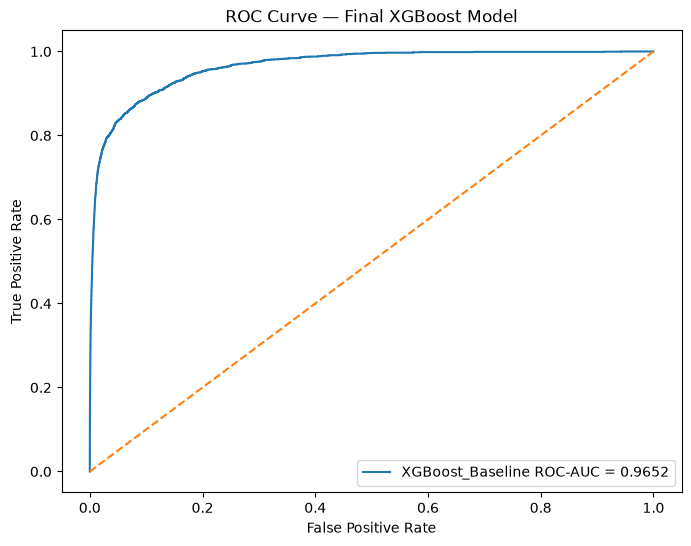

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    y_test,
    final_probability
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    fpr,
    tpr,
    label=f"{final_model_name} ROC-AUC = {final_roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final XGBoost Model")
plt.legend()

ROC_PATH = (
    FIGURES_DIR
    / "final_xgboost_roc_curve.png"
)

plt.savefig(
    ROC_PATH,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

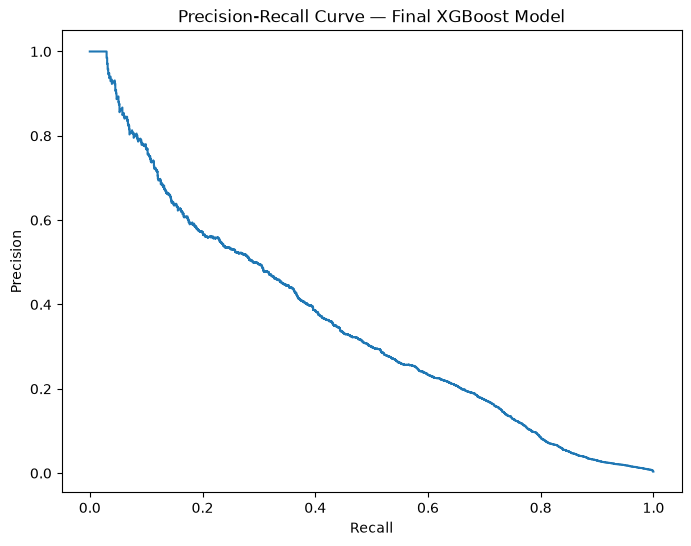

In [10]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, _ = (
    precision_recall_curve(
        y_test,
        final_probability
    )
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Final XGBoost Model")

PR_CURVE_PATH = (
    FIGURES_DIR
    / "final_xgboost_precision_recall_curve.png"
)

plt.savefig(
    PR_CURVE_PATH,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

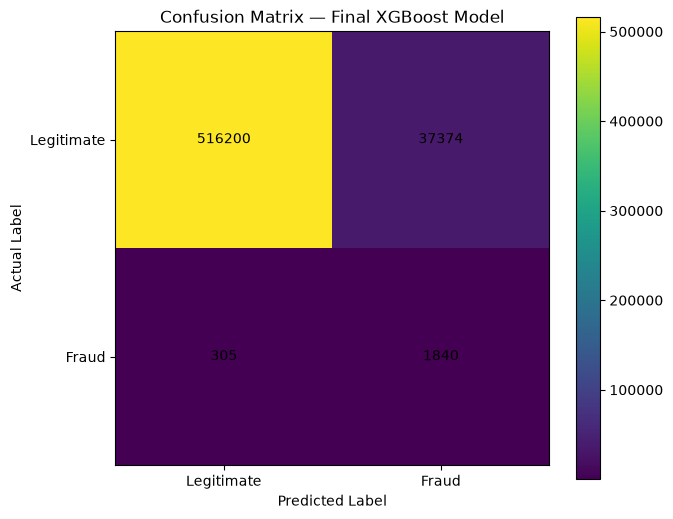

In [11]:
plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    confusion_matrix(
        y_test,
        final_prediction
    )
)

plt.title(
    "Confusion Matrix — Final XGBoost Model"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.yticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

matrix = confusion_matrix(
    y_test,
    final_prediction
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            matrix[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

CM_PATH = (
    FIGURES_DIR
    / "final_xgboost_confusion_matrix.png"
)

plt.savefig(
    CM_PATH,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [12]:
final_evaluation = {
    "selected_model": final_model_name,
    "feature_count": len(ML_FEATURES),
    "features": ML_FEATURES,
    "test_rows": int(len(X_test)),
    "threshold": 0.5,
    "accuracy": float(final_accuracy),
    "precision": float(final_precision),
    "recall": float(final_recall),
    "f1": float(final_f1),
    "roc_auc": float(final_roc_auc),
    "pr_auc": float(final_pr_auc)
}

FINAL_EVALUATION_PATH = (
    METRICS_DIR
    / "final_model_evaluation.json"
)

with open(
    FINAL_EVALUATION_PATH,
    "w"
) as file:
    json.dump(
        final_evaluation,
        file,
        indent=4
    )

print("========== EVALUATION SAVED ==========")
print(
    "Evaluation file:",
    FINAL_EVALUATION_PATH
)

print(
    "File exists:",
    FINAL_EVALUATION_PATH.exists()
)

print("=======================================")

========== EVALUATION SAVED ==========
Evaluation file: C:\Users\Lenovo\Desktop\Fraud-detection-ML-V2\outputs\metrics\final_model_evaluation.json
File exists: True


In [13]:
FINAL_MODEL_CANDIDATE_PATH = (
    MODELS_DIR
    / "xgboost_final_candidate.json"
)

final_model.save_model(
    FINAL_MODEL_CANDIDATE_PATH
)

print("========== FINAL MODEL CANDIDATE ==========")
print(
    "Selected model:",
    final_model_name
)

print(
    "Final candidate saved:",
    FINAL_MODEL_CANDIDATE_PATH.exists()
)

print(
    "Path:",
    FINAL_MODEL_CANDIDATE_PATH
)

print("===========================================")

========== FINAL MODEL CANDIDATE ==========
Selected model: XGBoost_Baseline
Final candidate saved: True
Path: C:\Users\Lenovo\Desktop\Fraud-detection-ML-V2\models\xgboost_final_candidate.json


In [14]:
print()
print("================================================")
print("     STREAMSENTINEL V2 — PHASE 6 SUMMARY")
print("================================================")

print()

print(
    "Selected model:",
    final_model_name
)

print(
    "Number of ML features:",
    len(ML_FEATURES)
)

print(
    "Test transactions:",
    len(X_test)
)

print()

print("Final Test Metrics")
print("------------------")

print(
    "Accuracy:",
    final_accuracy
)

print(
    "Precision:",
    final_precision
)

print(
    "Recall:",
    final_recall
)

print(
    "F1:",
    final_f1
)

print(
    "ROC-AUC:",
    final_roc_auc
)

print(
    "PR-AUC:",
    final_pr_auc
)

print()

print(
    "Final evaluation saved:",
    FINAL_EVALUATION_PATH.exists()
)

print(
    "Final model candidate saved:",
    FINAL_MODEL_CANDIDATE_PATH.exists()
)

print(
    "ROC curve saved:",
    ROC_PATH.exists()
)

print(
    "Precision-Recall curve saved:",
    PR_CURVE_PATH.exists()
)

print(
    "Confusion matrix saved:",
    CM_PATH.exists()
)

print()
print("PHASE 6 FINAL MODEL EVALUATION: COMPLETE")
print("================================================")


     STREAMSENTINEL V2 — PHASE 6 SUMMARY

Selected model: XGBoost_Baseline
Number of ML features: 6
Test transactions: 555719

Final Test Metrics
------------------
Accuracy: 0.9321977474227082
Precision: 0.04692201764675881
Recall: 0.8578088578088578
F1: 0.08897700621388331
ROC-AUC: 0.9652000907887204
PR-AUC: 0.3532678289861558

Final evaluation saved: True
Final model candidate saved: True
ROC curve saved: True
Precision-Recall curve saved: True
Confusion matrix saved: True

PHASE 6 FINAL MODEL EVALUATION: COMPLETE
